In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('/content/drive/MyDrive/Tiruppur_Data/TWQD_2000_to_2024_Yearly.csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

Dataset Shape: (325, 21)

First few rows:
   Sl.No            WellNo  Village  Latitude  Longtitude Month  Year    pH  \
0      1  W111105077163001  Avinasi   11.1847      77.275   May  2000  8.40   
1      2  W111105077163001  Avinasi   11.1847      77.275   May  2001  8.61   
2      3  W111105077163001  Avinasi   11.1847      77.275   May  2002  7.93   
3      4  W111105077163001  Avinasi   11.1847      77.275   May  2003  7.70   
4      5  W111105077163001  Avinasi   11.1847      77.275   May  2004  8.21   

     EC  HCO3  ...   Cl   SO4    NO3   Ca      Mg   Na     K     F   Fe   As  
0  1580   336  ...  230  73.0   32.0  102   52.00  152  26.0  0.91  0.0  0.0  
1  1940   769  ...  248   5.0   50.0  126   78.00  160  20.0  1.10  0.0  0.0  
2  2060   787  ...  298  40.0   65.0  132   84.00  195  35.0  1.20  0.0  0.0  
3  2520   652  ...  326   6.0   82.0  150  103.33  212  36.0  0.83  0.0  0.0  
4  2330   555  ...  362  55.0  177.0   64  111.92  210  45.0  0.86  0.0  0.0  

[5 rows 

=== BIS STANDARDS ANALYSIS ===
pH: 1.5% violations
EC: 67.7% violations
NO3: 69.8% violations
As: 0.0% violations
F: 7.4% violations
Cl: 64.9% violations
SO4: 31.1% violations
Ca: 59.7% violations
Mg: 82.8% violations


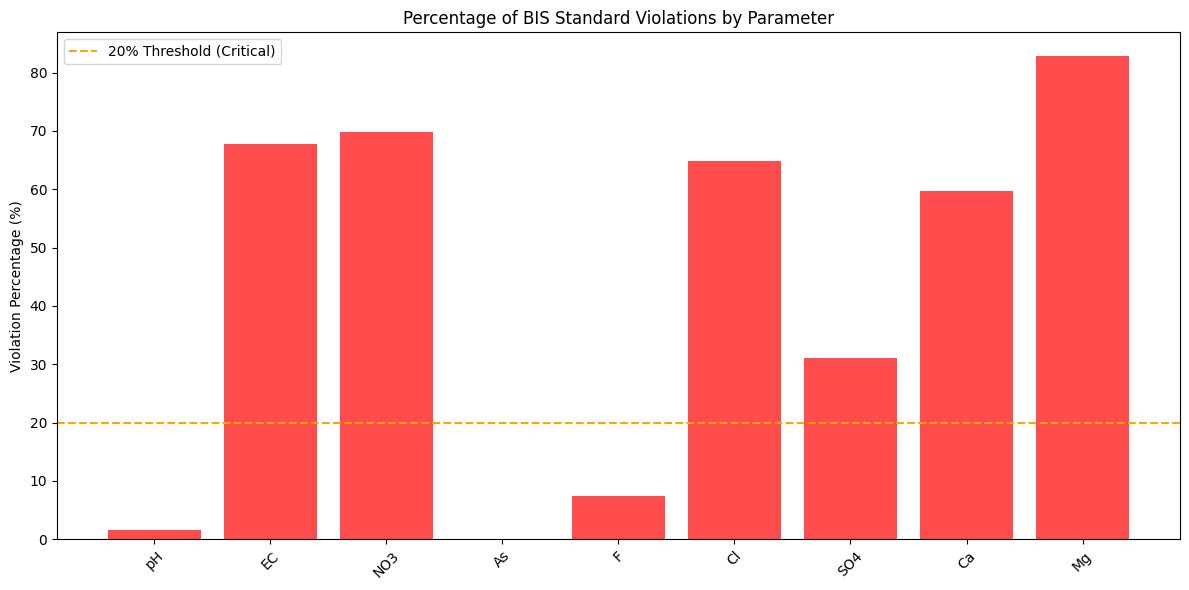

In [ ]:
# 1. HIGH-LEVEL DATA ANALYSIS WITH BIS STANDARDS

# Define BIS standards (IS 10500:2012)
bis_standards = {
    'pH': {'min': 6.5, 'max': 8.5},
    'EC': {'max': 1500},  # µS/cm (permissible up to 3000)
    'NO3': {'max': 45},
    'As': {'max': 0.01},
    'F': {'max': 1.5},
    'Cl': {'max': 250},
    'SO4': {'max': 200},
    'Ca': {'max': 75},
    'Mg': {'max': 30}
}

# Analyze violations
print("=== BIS STANDARDS ANALYSIS ===")
violations_summary = {}
for param, limits in bis_standards.items():
    if param in df.columns:
        if 'max' in limits:
            violations = (df[param] > limits['max']).sum()
            violation_percent = (violations / len(df)) * 100
        else:  # pH has both min and max
            violations = ((df[param] < limits['min']) | (df[param] > limits['max'])).sum()
            violation_percent = (violations / len(df)) * 100

        violations_summary[param] = violation_percent
        print(f"{param}: {violation_percent:.1f}% violations")

# Plot violations
plt.figure(figsize=(12, 6))
plt.bar(violations_summary.keys(), violations_summary.values(), color='red', alpha=0.7)
plt.axhline(y=20, color='orange', linestyle='--', label='20% Threshold (Critical)')
plt.title('Percentage of BIS Standard Violations by Parameter')
plt.ylabel('Violation Percentage (%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 2. DATA PREPROCESSING

# Handle missing values and zeros that might represent missing data
def preprocess_data(df):
    df_clean = df.copy()

    # Replace zeros with NaN for parameters that cannot be zero in natural water
    zero_tolerant_params = ['CO3', 'NO3']  # These can be zero
    for col in df_clean.columns:
        if col in ['pH', 'EC', 'HCO3', 'Cl', 'SO4', 'Ca', 'Mg', 'Na', 'K', 'F', 'Fe', 'As']:
            df_clean[col] = df_clean[col].replace(0, np.nan)

    # Forward fill missing values (temporal consistency)
    df_clean = df_clean.groupby('Village').apply(lambda x: x.ffill()).reset_index(drop=True)

    # If still missing, use village-wise median
    for col in df_clean.select_dtypes(include=[np.number]).columns:
        df_clean[col] = df_clean.groupby('Village')[col].transform(
            lambda x: x.fillna(x.median())
        )

    return df_clean

df_clean = preprocess_data(df)

# Feature Engineering
def create_features(df):
    df_featured = df.copy()

    # Temporal features
    df_featured['Year_norm'] = (df_featured['Year'] - 2000) / 25  # Normalize years

    # Village encoding
    le = LabelEncoder()
    df_featured['Village_encoded'] = le.fit_transform(df_featured['Village'])

    # Rate of change features (year-to-year differences)
    for village in df_featured['Village'].unique():
        village_mask = df_featured['Village'] == village
        for param in ['EC', 'NO3', 'pH', 'As', 'F']:
            df_featured.loc[village_mask, f'{param}_diff'] = df_featured.loc[village_mask, param].diff()

    # Fill NaN in difference columns
    diff_cols = [col for col in df_featured.columns if '_diff' in col]
    df_featured[diff_cols] = df_featured[diff_cols].fillna(0)

    return df_featured, le

df_processed, village_encoder = create_features(df_clean)

print("Processed dataset shape:", df_processed.shape)
print("\nNew features created:")
print([col for col in df_processed.columns if 'diff' in col or 'norm' in col or 'encoded' in col])

Processed dataset shape: (325, 28)

New features created:
['Year_norm', 'Village_encoded', 'EC_diff', 'NO3_diff', 'pH_diff', 'As_diff', 'F_diff']


In [ ]:
# 3. PREPARE DATA FOR LSTM

def create_sequences(data, villages, sequence_length=5, target_params=None):
    if target_params is None:
        target_params = ['pH', 'EC', 'NO3', 'As', 'F']

    X, y = [], []
    village_ids = []

    for village in villages:
        village_data = data[data['Village'] == village].sort_values('Year')

        # Select features
        feature_cols = ['pH', 'EC', 'HCO3', 'CO3', 'Cl', 'SO4', 'NO3', 'Ca', 'Mg', 'Na', 'K', 'F', 'Fe', 'As']
        feature_cols.extend([f'{param}_diff' for param in ['EC', 'NO3', 'pH', 'As', 'F']])
        feature_cols.extend(['Year_norm', 'Village_encoded'])

        values = village_data[feature_cols].values

        # Create sequences
        for i in range(len(values) - sequence_length):
            X.append(values[i:(i + sequence_length)])
            y.append(village_data[target_params].iloc[i + sequence_length].values)
            village_ids.append(village)

    return np.array(X), np.array(y), village_ids

# Target parameters for prediction
target_parameters = ['pH', 'EC', 'NO3', 'As', 'F']

# Create sequences
villages = df_processed['Village'].unique()
sequence_length = 5  # Use 5 years to predict the next

X, y, village_ids = create_sequences(df_processed, villages, sequence_length, target_parameters)

print(f"Sequences created: {X.shape}")
print(f"Targets shape: {y.shape}")

# Split data chronologically (time series split)
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
village_train, village_test = village_ids[:split_idx], village_ids[split_idx:]

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Sequences created: (260, 5, 21)
Targets shape: (260, 5)
Training set: (208, 5, 21), Test set: (52, 5, 21)


In [ ]:
# 4. BUILD AND TRAIN LSTM MODEL

def build_lstm_model(input_shape, output_dim):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(128, return_sequences=True, dropout=0.2),
        LSTM(64, dropout=0.2),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(output_dim)  # Output layer for multiple parameters
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    return model

# Build model
model = build_lstm_model((X_train.shape[1], X_train.shape[2]), y_train.shape[1])
print("Model Architecture:")
model.summary()

# Train model
early_stopping = EarlyStopping(patience=50, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 128)         │        76,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,901 (503.52 KB)

 Trainable params: 128,901 (503.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 196ms/step - loss: 921610.7500 - mae: 418.8269 - val_loss: 1326287.5000 - val_mae: 491.7833
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 966083.3750 - mae: 426.5596 - val_loss: 1325578.3750 - val_mae: 491.7336
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 952089.5000 - mae: 423.6060 - val_loss: 1324436.5000 - val_mae: 491.6320
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 947045.2500 - mae: 428.6862 - val_loss: 1322885.8750 - val_mae: 491.5186
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 819566.5000 - mae: 401.8891 - val_loss: 1320932.6250 - val_mae: 491.3672
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 867157.4375 - mae: 409.8804 - val_loss: 1318583.3750 - val_mae: 491.0367
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 904780.0625 - mae: 425.9335 - val_loss: 1315863.2500 - val_mae: 490.4610
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 894672.0000 - mae: 416.2

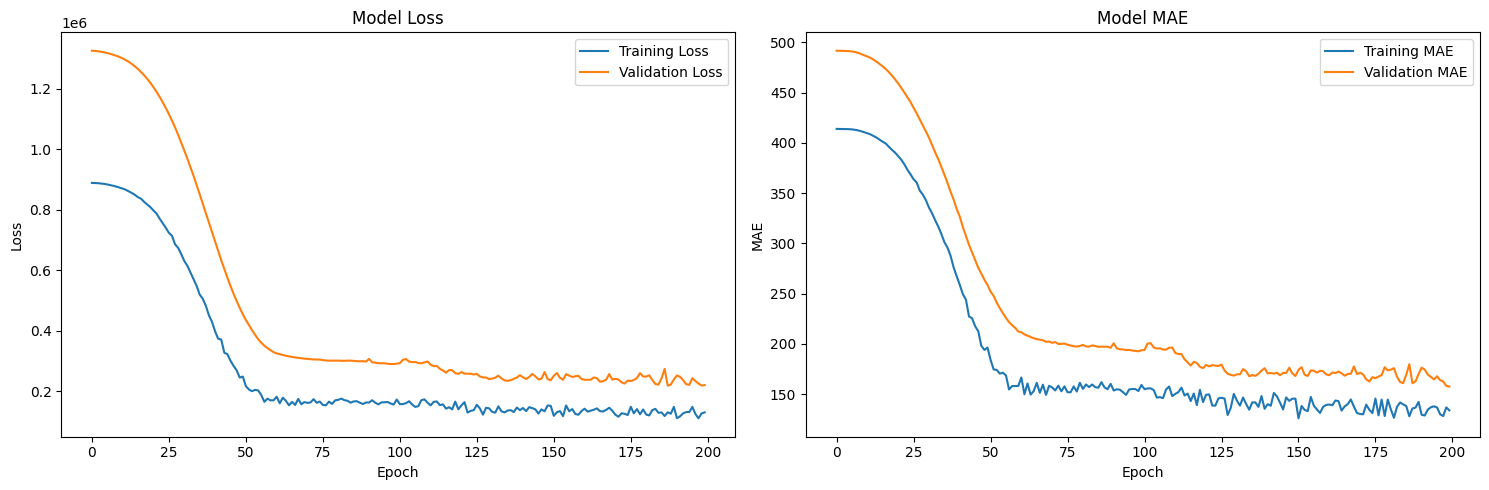

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 364ms/step

pH Performance:
  MAE: 2.0730
  RMSE: 2.4000
  R²: -85.0180

EC Performance:
  MAE: 729.2567
  RMSE: 972.1624
  R²: -0.0902

NO3 Performance:
  MAE: 87.7952
  RMSE: 98.9561
  R²: -0.9802

As Performance:
  MAE: 0.1837
  RMSE: 0.1913
  R²: -143833.6418

F Performance:
  MAE: 0.4597
  RMSE: 0.5510
  R²: -3.0114

Overall Performance:
Overall MAE: 163.9536
Overall RMSE: 437.0122


In [ ]:
# 5. MODEL EVALUATION

# Plot training history
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics for each parameter
metrics = {}
for i, param in enumerate(target_parameters):
    mae = mean_absolute_error(y_test[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test[:, i], y_pred[:, i]))
    r2 = r2_score(y_test[:, i], y_pred[:, i])

    metrics[param] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

    print(f"\n{param} Performance:")
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²: {r2:.4f}")

# Overall metrics
overall_mae = mean_absolute_error(y_test, y_pred)
overall_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nOverall Performance:")
print(f"Overall MAE: {overall_mae:.4f}")
print(f"Overall RMSE: {overall_rmse:.4f}")

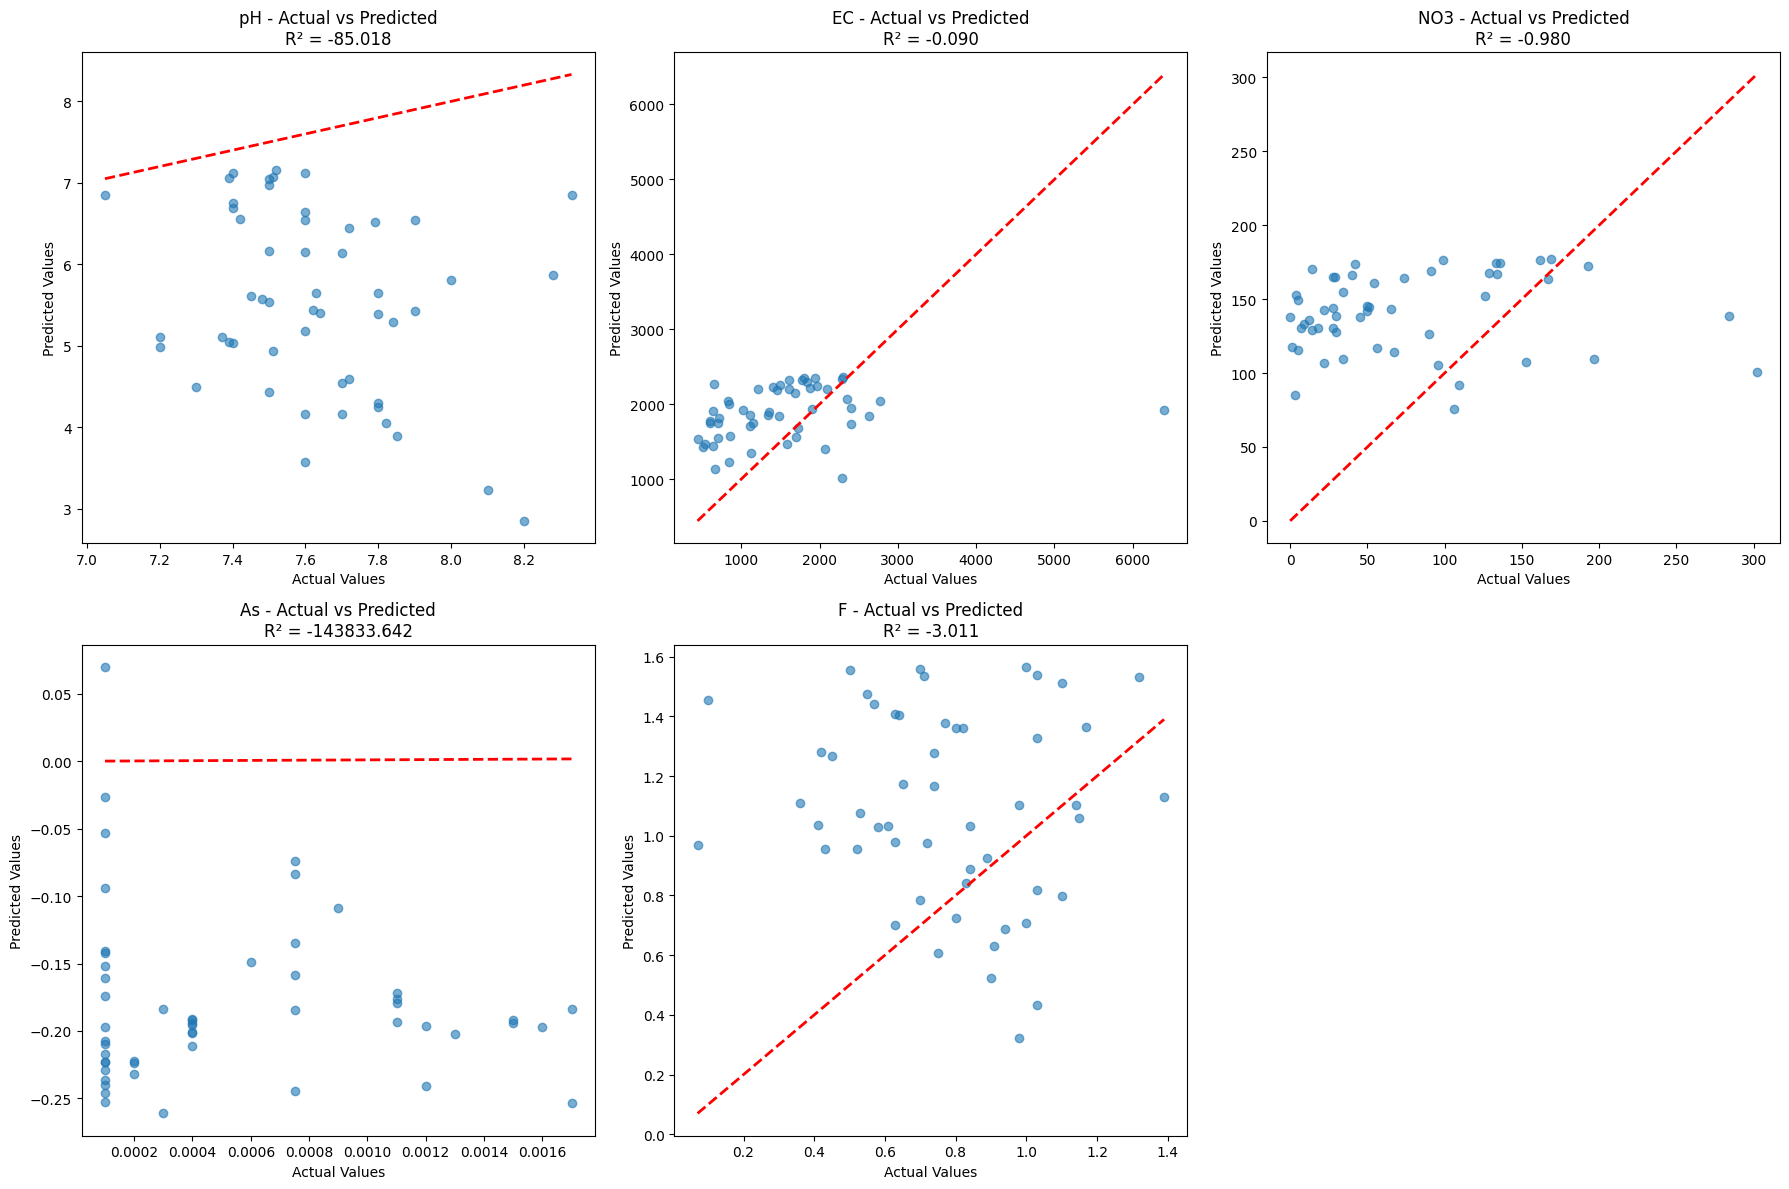

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


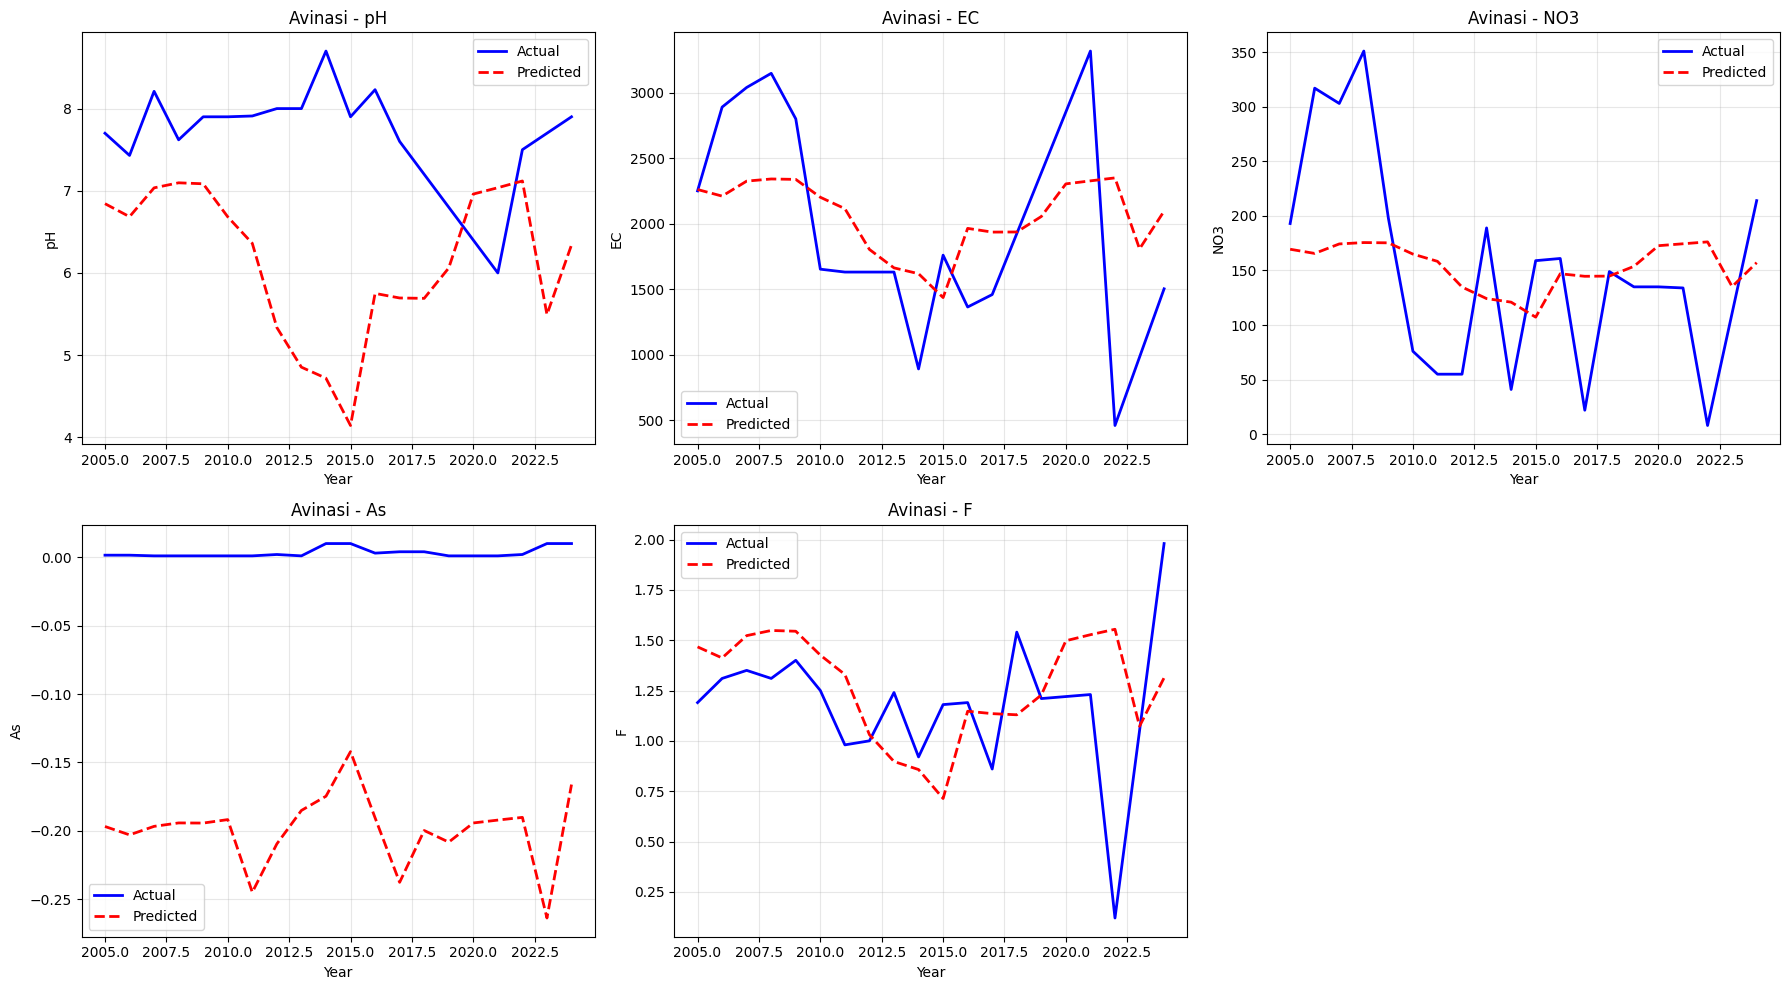

In [ ]:
# 6. VISUALIZATION OF PREDICTIONS

# Plot actual vs predicted for each parameter
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, param in enumerate(target_parameters):
    axes[i].scatter(y_test[:, i], y_pred[:, i], alpha=0.6)
    axes[i].plot([y_test[:, i].min(), y_test[:, i].max()],
                [y_test[:, i].min(), y_test[:, i].max()], 'r--', lw=2)
    axes[i].set_xlabel('Actual Values')
    axes[i].set_ylabel('Predicted Values')
    axes[i].set_title(f'{param} - Actual vs Predicted\nR² = {metrics[param]["R2"]:.3f}')

# Remove empty subplot
for i in range(len(target_parameters), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# Time series prediction visualization for a specific village
def plot_village_predictions(village_name, df_processed, model, sequence_length, target_parameters):
    village_data = df_processed[df_processed['Village'] == village_name].sort_values('Year')

    # Prepare features for this village
    feature_cols = ['pH', 'EC', 'HCO3', 'CO3', 'Cl', 'SO4', 'NO3', 'Ca', 'Mg', 'Na', 'K', 'F', 'Fe', 'As']
    feature_cols.extend([f'{param}_diff' for param in ['EC', 'NO3', 'pH', 'As', 'F']])
    feature_cols.extend(['Year_norm', 'Village_encoded'])

    # Create sequences for prediction
    X_village = []
    years = []
    for i in range(len(village_data) - sequence_length):
        X_village.append(village_data[feature_cols].iloc[i:(i + sequence_length)].values)
        years.append(village_data['Year'].iloc[i + sequence_length])

    X_village = np.array(X_village)

    # Predict
    if len(X_village) > 0:
        y_village_pred = model.predict(X_village)

        # Plot
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.ravel()

        actual_years = village_data['Year'].values[sequence_length:]
        for j, param in enumerate(target_parameters):
            axes[j].plot(actual_years, village_data[param].values[sequence_length:],
                       'b-', label='Actual', linewidth=2)
            axes[j].plot(years, y_village_pred[:, j], 'r--', label='Predicted', linewidth=2)
            axes[j].set_title(f'{village_name} - {param}')
            axes[j].set_xlabel('Year')
            axes[j].set_ylabel(param)
            axes[j].legend()
            axes[j].grid(True, alpha=0.3)

        # Remove empty subplots
        for j in range(len(target_parameters), len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

# Plot for a specific village
plot_village_predictions('Avinasi', df_processed, model, sequence_length, target_parameters)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
=== PREDICTIONS FOR 2025 ===
         Village  Year      pH           EC         NO3      As       F
0        Avinasi  2025  6.9106  2286.362305  171.446198 -0.1996  1.4915
1     Dharapuram  2025  5.6768  1926.609741  144.380096 -0.1178  1.0918
2   Gudimangalam  2025  6.3105  2111.581055  158.103195 -0.2146  1.2999
3       Kangeyam  2025  6.7682  2242.011230  168.044098 -0.2041  1.4373
4       Kundadam  2025  6.1627  2063.542480  154.453705 -0.2147  1.2395
5   Madathukulam  2025  6.8314  2248.99072

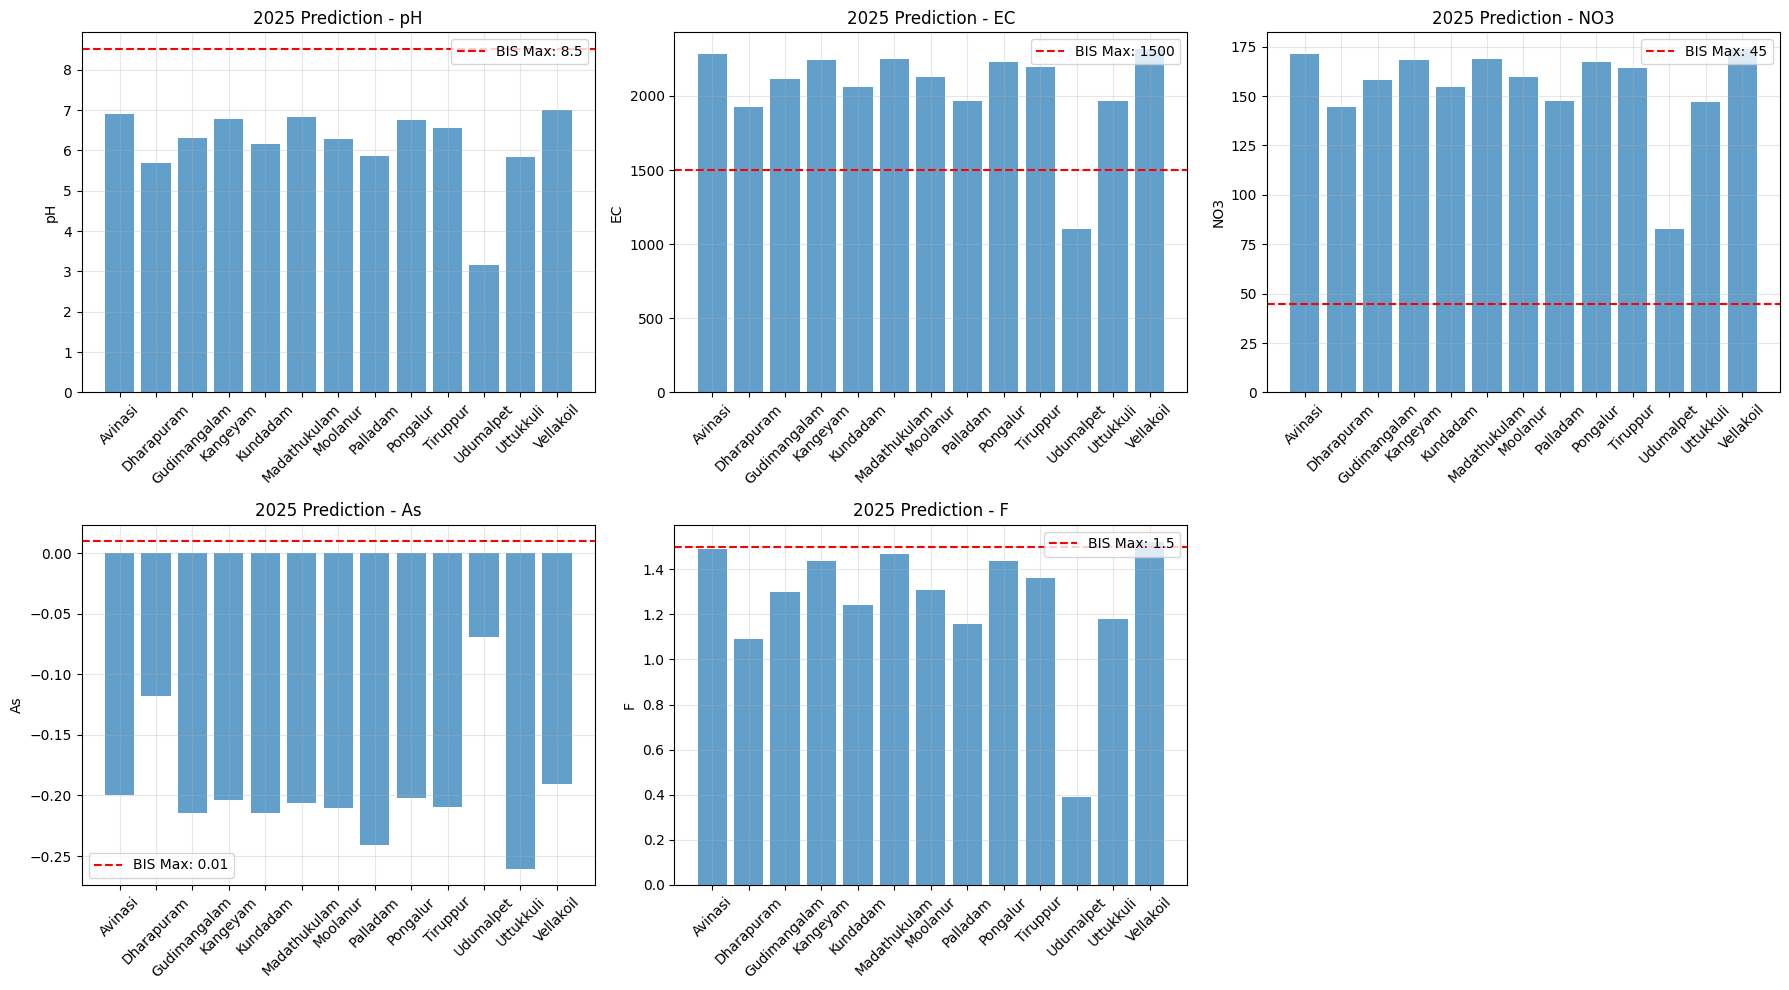

In [ ]:
# 7. PREDICT NEXT YEAR (2025)

def predict_next_year(df_processed, model, sequence_length, villages, target_parameters):
    predictions_2025 = []

    feature_cols = ['pH', 'EC', 'HCO3', 'CO3', 'Cl', 'SO4', 'NO3', 'Ca', 'Mg', 'Na', 'K', 'F', 'Fe', 'As']
    feature_cols.extend([f'{param}_diff' for param in ['EC', 'NO3', 'pH', 'As', 'F']])
    feature_cols.extend(['Year_norm', 'Village_encoded'])

    for village in villages:
        village_data = df_processed[df_processed['Village'] == village].sort_values('Year')

        if len(village_data) >= sequence_length:
            # Get the last sequence
            last_sequence = village_data[feature_cols].iloc[-sequence_length:].values
            last_sequence = last_sequence.reshape(1, sequence_length, len(feature_cols))

            # Predict
            pred = model.predict(last_sequence)[0]

            predictions_2025.append({
                'Village': village,
                'Year': 2025,
                **{target_parameters[i]: pred[i] for i in range(len(target_parameters))}
            })

    return pd.DataFrame(predictions_2025)

# Predict 2025 values
predictions_2025 = predict_next_year(df_processed, model, sequence_length, villages, target_parameters)

print("=== PREDICTIONS FOR 2025 ===")
print(predictions_2025.round(4))

# Check BIS compliance for 2025 predictions
print("\n=== BIS COMPLIANCE CHECK FOR 2025 PREDICTIONS ===")
for param in target_parameters:
    if param in bis_standards:
        if 'max' in bis_standards[param]:
            violations = (predictions_2025[param] > bis_standards[param]['max']).sum()
        else:  # pH
            violations = ((predictions_2025[param] < bis_standards[param]['min']) |
                         (predictions_2025[param] > bis_standards[param]['max'])).sum()

        print(f"{param}: {violations} villages predicted to violate BIS standards")

# Visualize 2025 predictions with BIS limits
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, param in enumerate(target_parameters):
    if param in bis_standards:
        axes[i].bar(predictions_2025['Village'], predictions_2025[param], alpha=0.7)

        # Add BIS limit lines
        if 'max' in bis_standards[param]:
            axes[i].axhline(y=bis_standards[param]['max'], color='red', linestyle='--',
                          label=f'BIS Max: {bis_standards[param]["max"]}')
        else:  # pH
            axes[i].axhline(y=bis_standards[param]['min'], color='red', linestyle='--',
                          label=f'BIS Min: {bis_standards[param]["min"]}')
            axes[i].axhline(y=bis_standards[param]['max'], color='red', linestyle='--',
                          label=f'BIS Max: {bis_standards[param]["max"]}')

        axes[i].set_title(f'2025 Prediction - {param}')
        axes[i].set_ylabel(param)
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

# Remove empty subplots
for i in range(len(target_parameters), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
import warnings
warnings.filterwarnings('ignore')

# Reload and re-preprocess data for ML approach
df = pd.read_csv('/content/drive/MyDrive/Tiruppur_Data/TWQD_2000_to_2024_Yearly.csv')

# Enhanced preprocessing for ML
def enhanced_preprocessing(df):
    df_clean = df.copy()

    # Handle zeros and missing values more carefully
    for col in df_clean.select_dtypes(include=[np.number]).columns:
        if col not in ['Sl.No', 'Year', 'Month', 'Latitude', 'Longtitude']:
            # Replace zeros with village-wise median for parameters that shouldn't be zero
            if col not in ['CO3', 'NO3']:  # These can be zero
                df_clean[col] = df_clean.groupby('Village')[col].transform(
                    lambda x: x.replace(0, x.median())
                )

    # Feature engineering for ML
    df_clean['Year_norm'] = (df_clean['Year'] - 2000) / 25

    # Village encoding
    le = LabelEncoder()
    df_clean['Village_encoded'] = le.fit_transform(df_clean['Village'])

    # Create lag features (more effective than differences for ML)
    lag_features = ['pH', 'EC', 'NO3', 'As', 'F', 'Cl', 'Ca', 'Mg']
    for village in df_clean['Village'].unique():
        village_mask = df_clean['Village'] == village
        for feature in lag_features:
            for lag in [1, 2, 3]:  # Create lags of 1, 2, 3 years
                df_clean.loc[village_mask, f'{feature}_lag_{lag}'] = \
                    df_clean.loc[village_mask, feature].shift(lag)

    # Create rolling statistics
    for village in df_clean['Village'].unique():
        village_mask = df_clean['Village'] == village
        for feature in lag_features:
            df_clean.loc[village_mask, f'{feature}_rolling_mean_3'] = \
                df_clean.loc[village_mask, feature].rolling(window=3, min_periods=1).mean()
            df_clean.loc[village_mask, f'{feature}_rolling_std_3'] = \
                df_clean.loc[village_mask, feature].rolling(window=3, min_periods=1).std()

    # Fill NaN values created by lag features
    df_clean = df_clean.fillna(method='bfill').fillna(method='ffill')

    return df_clean, le

df_processed, village_encoder = enhanced_preprocessing(df)
print("Enhanced dataset shape:", df_processed.shape)
print("New features:", [col for col in df_processed.columns if 'lag' in col or 'rolling' in col])

Enhanced dataset shape: (325, 63)
New features: ['Village', 'Village_encoded', 'pH_lag_1', 'pH_lag_2', 'pH_lag_3', 'EC_lag_1', 'EC_lag_2', 'EC_lag_3', 'NO3_lag_1', 'NO3_lag_2', 'NO3_lag_3', 'As_lag_1', 'As_lag_2', 'As_lag_3', 'F_lag_1', 'F_lag_2', 'F_lag_3', 'Cl_lag_1', 'Cl_lag_2', 'Cl_lag_3', 'Ca_lag_1', 'Ca_lag_2', 'Ca_lag_3', 'Mg_lag_1', 'Mg_lag_2', 'Mg_lag_3', 'pH_rolling_mean_3', 'pH_rolling_std_3', 'EC_rolling_mean_3', 'EC_rolling_std_3', 'NO3_rolling_mean_3', 'NO3_rolling_std_3', 'As_rolling_mean_3', 'As_rolling_std_3', 'F_rolling_mean_3', 'F_rolling_std_3', 'Cl_rolling_mean_3', 'Cl_rolling_std_3', 'Ca_rolling_mean_3', 'Ca_rolling_std_3', 'Mg_rolling_mean_3', 'Mg_rolling_std_3']


In [ ]:
# Prepare features and target for ML
def prepare_ml_data(df, target_params):
    # Use only complete cases (remove rows with NaN in targets)
    df_complete = df.dropna(subset=target_params)

    # Feature selection
    exclude_cols = ['Sl.No', 'WellNo', 'Village', 'Month', 'Year', 'Latitude', 'Longtitude']
    feature_cols = [col for col in df_complete.columns if col not in exclude_cols + target_params]

    X = df_complete[feature_cols]
    y = df_complete[target_params]

    return X, y, df_complete

target_parameters = ['pH', 'EC', 'NO3', 'As', 'F']
X, y, df_ml = prepare_ml_data(df_processed, target_parameters)

print(f"Features: {X.shape}")
print(f"Targets: {y.shape}")
print(f"Feature names: {list(X.columns)}")

Features: (325, 51)
Targets: (325, 5)
Feature names: ['HCO3', 'CO3', 'Cl', 'SO4', 'Ca', 'Mg', 'Na', 'K', 'Fe', 'Year_norm', 'Village_encoded', 'pH_lag_1', 'pH_lag_2', 'pH_lag_3', 'EC_lag_1', 'EC_lag_2', 'EC_lag_3', 'NO3_lag_1', 'NO3_lag_2', 'NO3_lag_3', 'As_lag_1', 'As_lag_2', 'As_lag_3', 'F_lag_1', 'F_lag_2', 'F_lag_3', 'Cl_lag_1', 'Cl_lag_2', 'Cl_lag_3', 'Ca_lag_1', 'Ca_lag_2', 'Ca_lag_3', 'Mg_lag_1', 'Mg_lag_2', 'Mg_lag_3', 'pH_rolling_mean_3', 'pH_rolling_std_3', 'EC_rolling_mean_3', 'EC_rolling_std_3', 'NO3_rolling_mean_3', 'NO3_rolling_std_3', 'As_rolling_mean_3', 'As_rolling_std_3', 'F_rolling_mean_3', 'F_rolling_std_3', 'Cl_rolling_mean_3', 'Cl_rolling_std_3', 'Ca_rolling_mean_3', 'Ca_rolling_std_3', 'Mg_rolling_mean_3', 'Mg_rolling_std_3']


In [ ]:
# Split data with stratification by village
villages = df_ml['Village']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=villages
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

Training set: (260, 51)
Test set: (65, 51)


In [ ]:
# Initialize and train multiple ML models
models = {
    'Random Forest': MultiOutputRegressor(RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        min_samples_split=5
    )),
    'Gradient Boosting': MultiOutputRegressor(GradientBoostingRegressor(
        n_estimators=100,
        random_state=42,
        max_depth=5,
        learning_rate=0.1
    )),
    'Ridge Regression': MultiOutputRegressor(Ridge(alpha=1.0)),
    'Lasso Regression': MultiOutputRegressor(Lasso(alpha=0.1)),
    'SVR': MultiOutputRegressor(SVR(kernel='rbf', C=1.0))
}

# Train and evaluate models
results = {}
predictions = {}

for name, model in models.items():
    print(f"Training {name}...")

    # Train model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Store predictions
    predictions[name] = y_pred

    # Calculate metrics for each parameter
    param_metrics = {}
    for i, param in enumerate(target_parameters):
        mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
        r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])

        param_metrics[param] = {
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2
        }

    # Overall metrics
    overall_mae = mean_absolute_error(y_test, y_pred)
    overall_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[name] = {
        'param_metrics': param_metrics,
        'overall_mae': overall_mae,
        'overall_rmse': overall_rmse,
        'model': model
    }

    print(f"{name} - Overall MAE: {overall_mae:.4f}, RMSE: {overall_rmse:.4f}")

Training Random Forest...
Random Forest - Overall MAE: 64.2853, RMSE: 173.7830
Training Gradient Boosting...
Gradient Boosting - Overall MAE: 51.8602, RMSE: 125.5562
Training Ridge Regression...
Ridge Regression - Overall MAE: 20.4393, RMSE: 69.3588
Training Lasso Regression...
Lasso Regression - Overall MAE: 9.1782, RMSE: 50.9936
Training SVR...
SVR - Overall MAE: 156.0924, RMSE: 438.9488


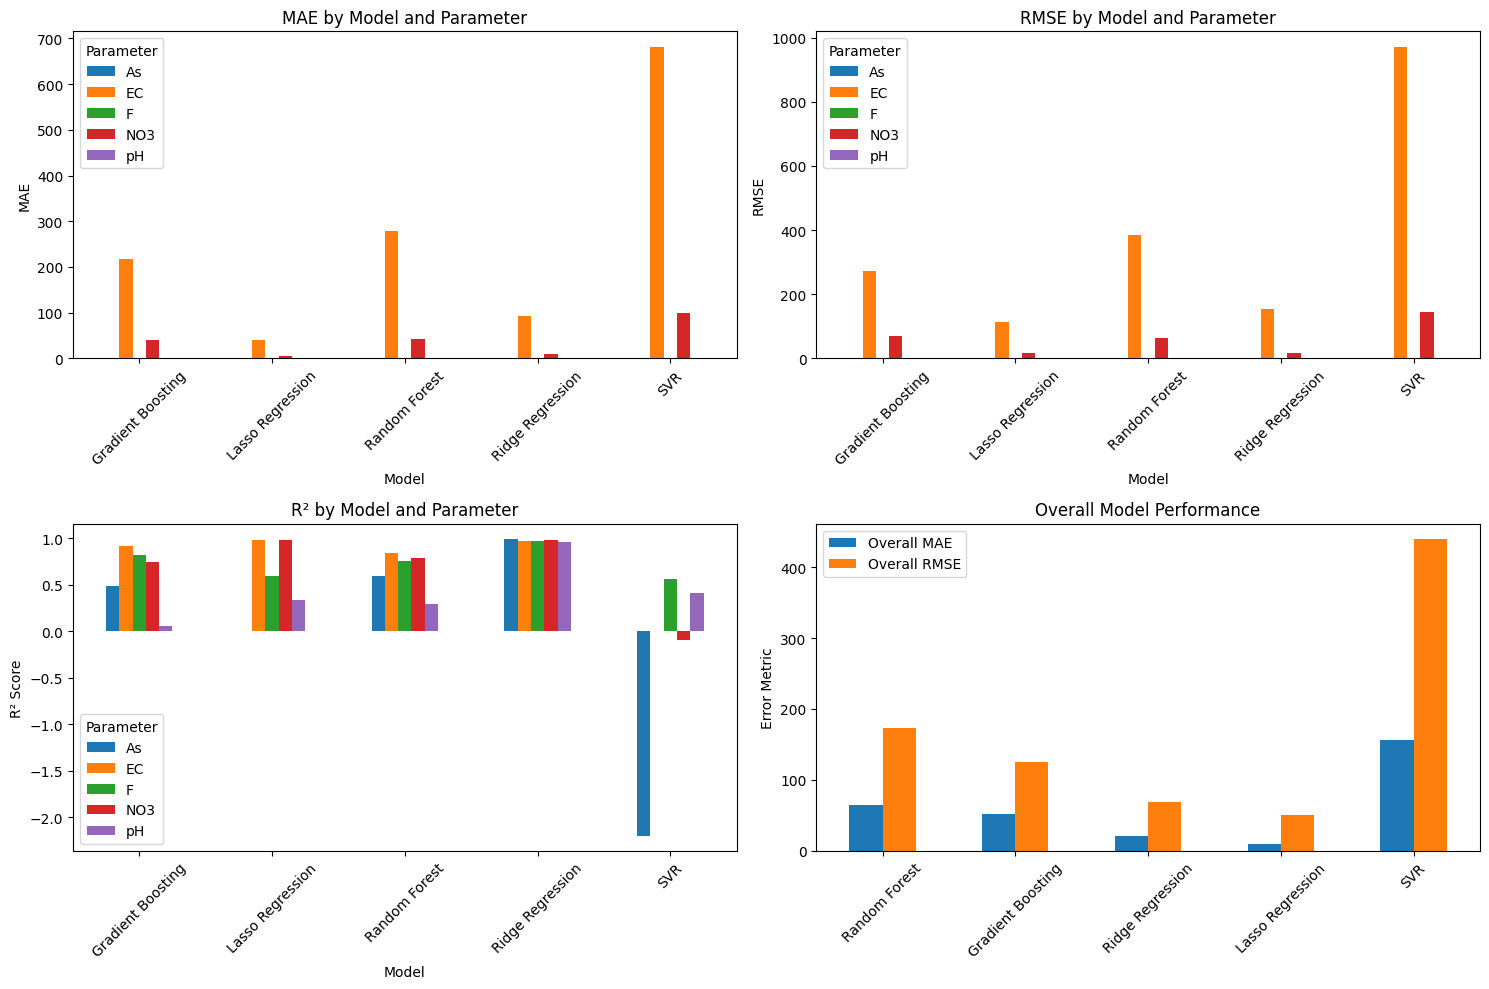

=== DETAILED MODEL PERFORMANCE ===

Random Forest:
Overall MAE: 64.2853
Overall RMSE: 173.7830
  pH: MAE=0.2066, R²=0.2972
  EC: MAE=278.5751, R²=0.8442
  NO3: MAE=42.5089, R²=0.7838
  As: MAE=0.0008, R²=0.5918
  F: MAE=0.1351, R²=0.7576

Gradient Boosting:
Overall MAE: 51.8602
Overall RMSE: 125.5562
  pH: MAE=0.2112, R²=0.0546
  EC: MAE=218.5290, R²=0.9216
  NO3: MAE=40.4389, R²=0.7417
  As: MAE=0.0008, R²=0.4910
  F: MAE=0.1213, R²=0.8158

Ridge Regression:
Overall MAE: 20.4393
Overall RMSE: 69.3588
  pH: MAE=0.0406, R²=0.9615
  EC: MAE=92.4310, R²=0.9748
  NO3: MAE=9.6860, R²=0.9851
  As: MAE=0.0001, R²=0.9965
  F: MAE=0.0389, R²=0.9729

Lasso Regression:
Overall MAE: 9.1782
Overall RMSE: 50.9936
  pH: MAE=0.2193, R²=0.3384
  EC: MAE=39.8719, R²=0.9865
  NO3: MAE=5.6100, R²=0.9867
  As: MAE=0.0014, R²=-0.0025
  F: MAE=0.1884, R²=0.5999

SVR:
Overall MAE: 156.0924
Overall RMSE: 438.9488
  pH: MAE=0.2202, R²=0.4121
  EC: MAE=681.3973, R²=0.0004
  NO3: MAE=98.6461, R²=-0.0911
  As: MAE

In [ ]:
# Compare model performance
comparison_data = []
for model_name, result in results.items():
    for param in target_parameters:
        comparison_data.append({
            'Model': model_name,
            'Parameter': param,
            'MAE': result['param_metrics'][param]['MAE'],
            'RMSE': result['param_metrics'][param]['RMSE'],
            'R2': result['param_metrics'][param]['R2']
        })

comparison_df = pd.DataFrame(comparison_data)

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# MAE comparison
mae_pivot = comparison_df.pivot(index='Model', columns='Parameter', values='MAE')
mae_pivot.plot(kind='bar', ax=axes[0,0], title='MAE by Model and Parameter')
axes[0,0].set_ylabel('MAE')
axes[0,0].tick_params(axis='x', rotation=45)

# RMSE comparison
rmse_pivot = comparison_df.pivot(index='Model', columns='Parameter', values='RMSE')
rmse_pivot.plot(kind='bar', ax=axes[0,1], title='RMSE by Model and Parameter')
axes[0,1].set_ylabel('RMSE')
axes[0,1].tick_params(axis='x', rotation=45)

# R² comparison
r2_pivot = comparison_df.pivot(index='Model', columns='Parameter', values='R2')
r2_pivot.plot(kind='bar', ax=axes[1,0], title='R² by Model and Parameter')
axes[1,0].set_ylabel('R² Score')
axes[1,0].tick_params(axis='x', rotation=45)

# Overall performance
overall_metrics = pd.DataFrame({
    model: [results[model]['overall_mae'], results[model]['overall_rmse']]
    for model in results.keys()
}, index=['Overall MAE', 'Overall RMSE']).T
overall_metrics.plot(kind='bar', ax=axes[1,1], title='Overall Model Performance')
axes[1,1].set_ylabel('Error Metric')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print detailed results
print("=== DETAILED MODEL PERFORMANCE ===")
for model_name in results.keys():
    print(f"\n{model_name}:")
    print(f"Overall MAE: {results[model_name]['overall_mae']:.4f}")
    print(f"Overall RMSE: {results[model_name]['overall_rmse']:.4f}")
    for param in target_parameters:
        metrics = results[model_name]['param_metrics'][param]
        print(f"  {param}: MAE={metrics['MAE']:.4f}, R²={metrics['R2']:.4f}")

In [ ]:
# Select best model based on overall MAE
best_model_name = min(results.keys(), key=lambda x: results[x]['overall_mae'])
best_model = results[best_model_name]['model']
print(f"\n*** BEST MODEL: {best_model_name} ***")

# Feature importance for the best model (if available)
if 'Forest' in best_model_name or 'Boosting' in best_model_name:
    try:
        # For tree-based models
        feature_importance = best_model.estimators_[0].feature_importances_
        feature_importance_df = pd.DataFrame({
            'feature': X.columns,
            'importance': feature_importance
        }).sort_values('importance', ascending=False)

        plt.figure(figsize=(10, 6))
        plt.barh(feature_importance_df['feature'][:15],
                feature_importance_df['importance'][:15])
        plt.title(f'Top 15 Feature Importance - {best_model_name}')
        plt.xlabel('Importance Score')
        plt.tight_layout()
        plt.show()
    except:
        print("Feature importance not available for this model")


*** BEST MODEL: Lasso Regression ***


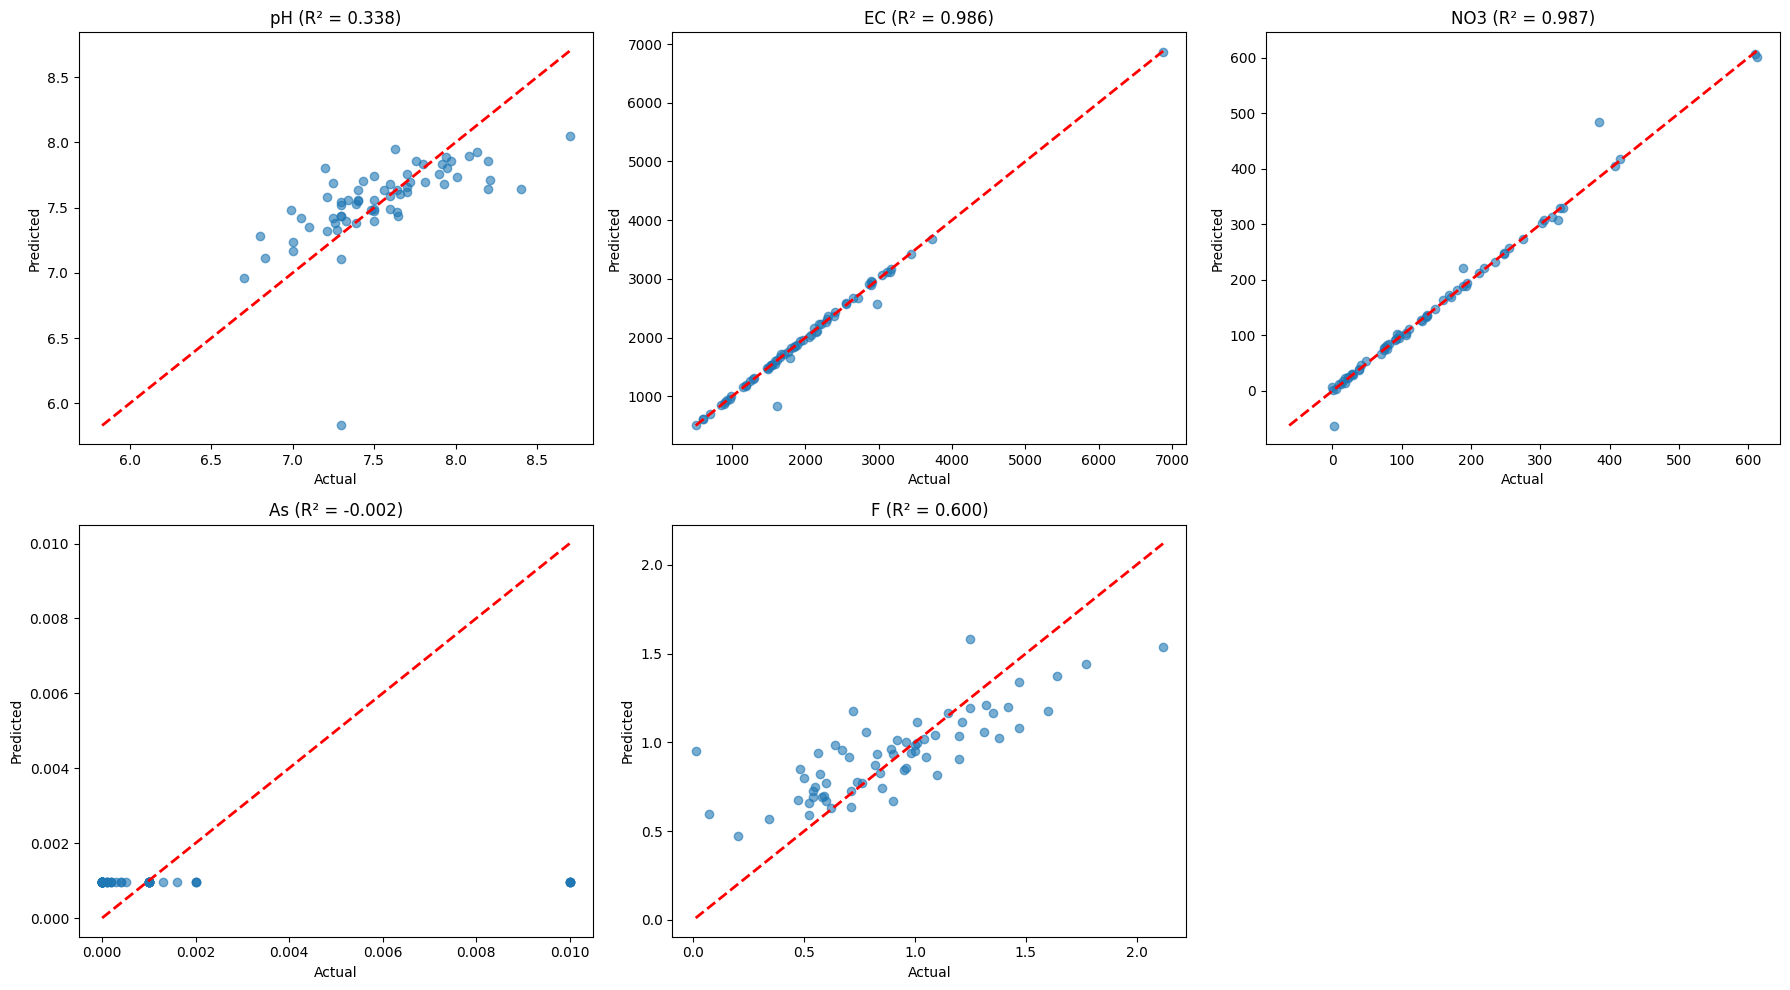

In [ ]:
# Visualize predictions vs actual for best model
best_predictions = predictions[best_model_name]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, param in enumerate(target_parameters):
    axes[i].scatter(y_test.iloc[:, i], best_predictions[:, i], alpha=0.6)
    min_val = min(y_test.iloc[:, i].min(), best_predictions[:, i].min())
    max_val = max(y_test.iloc[:, i].max(), best_predictions[:, i].max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')
    r2 = results[best_model_name]['param_metrics'][param]['R2']
    axes[i].set_title(f'{param} (R² = {r2:.3f})')

# Remove empty subplot
for i in range(len(target_parameters), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

=== 2025 PREDICTIONS USING BEST ML MODEL ===
         Village  Year      pH         EC       NO3     As       F
0        Avinasi  2025  7.6528  1521.4866  208.6280  0.001  1.0093
1     Dharapuram  2025  7.6436  3681.0551  181.2352  0.001  0.8011
2   Gudimangalam  2025  7.3168  1666.4103  346.7741  0.001  0.8056
3       Kangeyam  2025  7.4223  1994.7524  201.2698  0.001  0.5815
4       Kundadam  2025  7.8771  1837.0288   75.7311  0.001  0.8214
5   Madathukulam  2025  7.5238  1463.4023   12.7717  0.001  0.6268
6       Moolanur  2025  7.5270  2118.1041   15.9608  0.001  0.9074
7       Palladam  2025  7.4581  1200.0061  129.0778  0.001  0.7105
8       Pongalur  2025  7.5078  2675.6665  264.1018  0.001  0.9369
9       Tiruppur  2025  7.4040  2479.3653  112.6582  0.001  1.1089
10     Udumalpet  2025  7.4894   512.3728   22.5523  0.001  0.6585
11     Uttukkuli  2025  7.5498  1960.7588  126.7921  0.001  0.8192
12     Vellakoil  2025  7.7479  2356.3960   34.8977  0.001  0.7264

=== BIS COMPLIAN

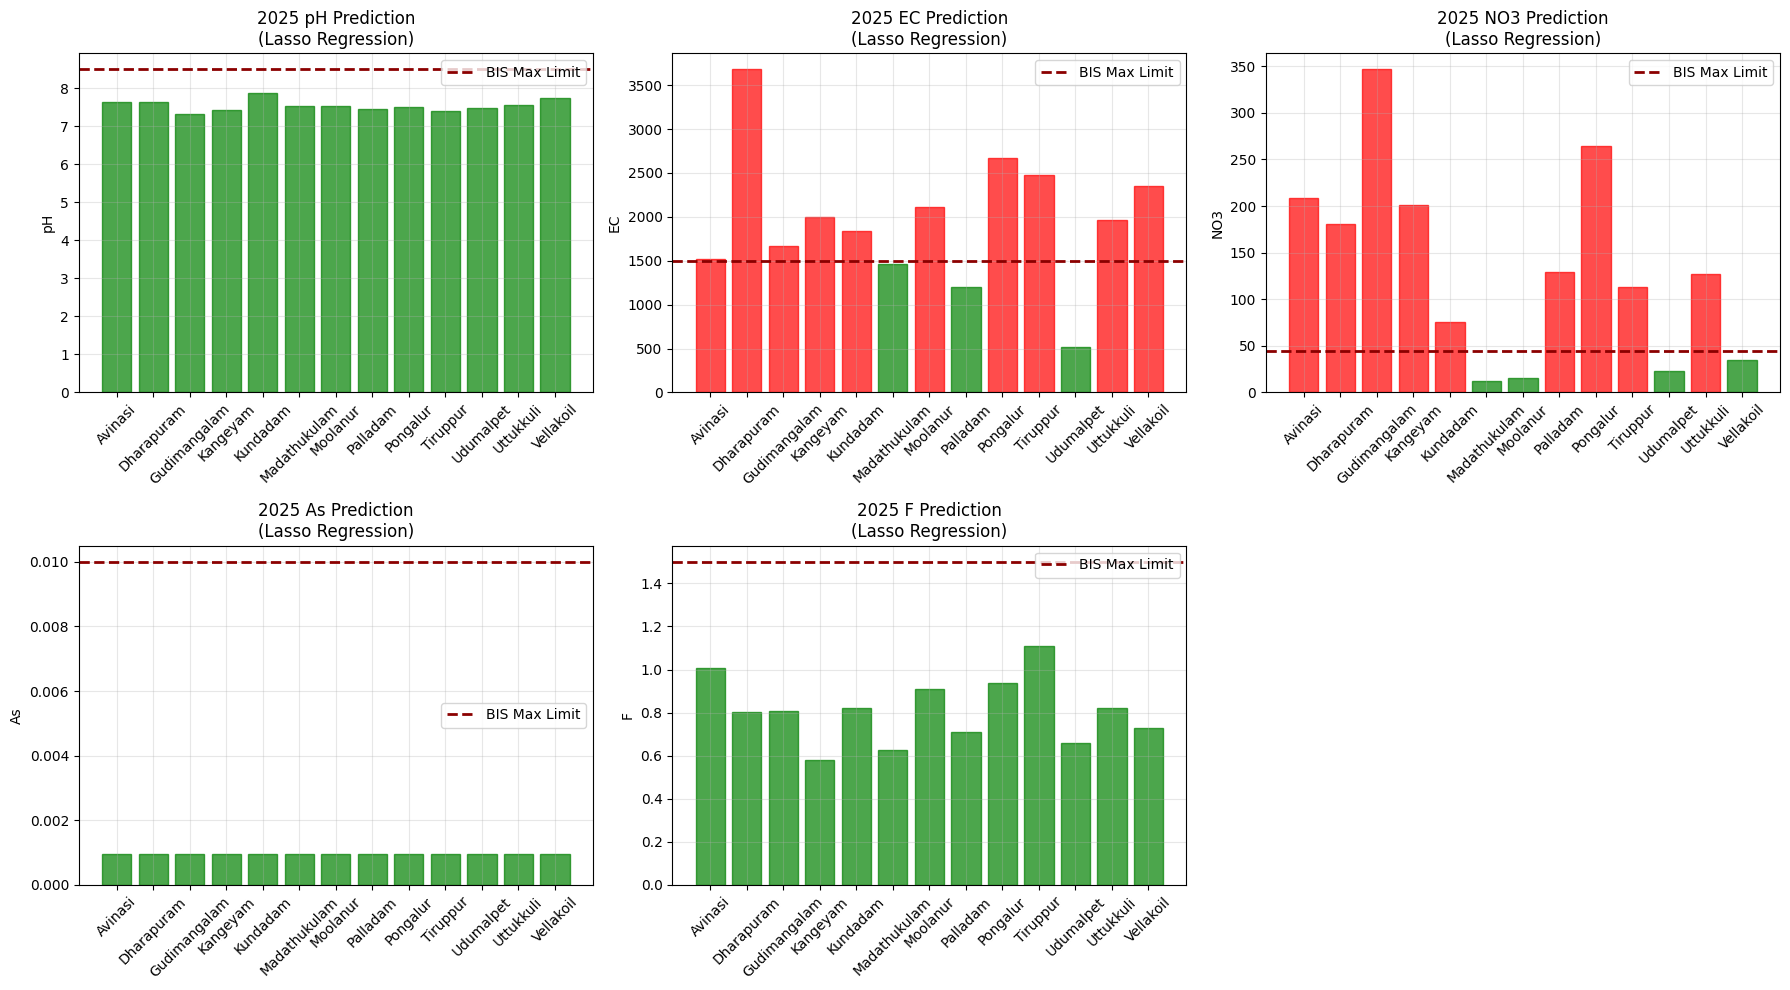

In [ ]:
# Predict 2025 values using the best model
def predict_2025_ml(df_processed, model, scaler, target_params):
    predictions_2025 = []

    for village in df_processed['Village'].unique():
        village_data = df_processed[df_processed['Village'] == village].sort_values('Year')

        # Get the latest data point (2024)
        latest_data = village_data.iloc[-1:].copy()

        # Prepare features for prediction
        exclude_cols = ['Sl.No', 'WellNo', 'Village', 'Month', 'Year', 'Latitude', 'Longtitude']
        feature_cols = [col for col in latest_data.columns if col not in exclude_cols + target_params]

        X_2025 = latest_data[feature_cols]

        # Scale features
        X_2025_scaled = scaler.transform(X_2025)

        # Predict
        pred_2025 = model.predict(X_2025_scaled)[0]

        predictions_2025.append({
            'Village': village,
            'Year': 2025,
            **{target_params[i]: pred_2025[i] for i in range(len(target_params))}
        })

    return pd.DataFrame(predictions_2025)

# Make 2025 predictions
predictions_2025_ml = predict_2025_ml(df_processed, best_model, scaler, target_parameters)

print("=== 2025 PREDICTIONS USING BEST ML MODEL ===")
print(predictions_2025_ml.round(4))

# BIS compliance check for 2025
bis_standards = {
    'pH': {'min': 6.5, 'max': 8.5},
    'EC': {'max': 1500},
    'NO3': {'max': 45},
    'As': {'max': 0.01},
    'F': {'max': 1.5}
}

print("\n=== BIS COMPLIANCE CHECK FOR 2025 ===")
for param in target_parameters:
    if param in bis_standards:
        if 'max' in bis_standards[param]:
            violations = (predictions_2025_ml[param] > bis_standards[param]['max']).sum()
        else:
            violations = ((predictions_2025_ml[param] < bis_standards[param]['min']) |
                         (predictions_2025_ml[param] > bis_standards[param]['max'])).sum()

        print(f"{param}: {violations} villages predicted to violate BIS standards")

# Visualize 2025 predictions with BIS limits
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, param in enumerate(target_parameters):
    if param in bis_standards:
        bars = axes[i].bar(predictions_2025_ml['Village'], predictions_2025_ml[param], alpha=0.7)

        # Color bars based on BIS compliance
        for j, (village, value) in enumerate(zip(predictions_2025_ml['Village'], predictions_2025_ml[param])):
            if 'max' in bis_standards[param]:
                color = 'red' if value > bis_standards[param]['max'] else 'green'
            else:
                color = 'red' if (value < bis_standards[param]['min'] or value > bis_standards[param]['max']) else 'green'
            bars[j].set_color(color)

        # Add BIS limit lines
        if 'max' in bis_standards[param]:
            axes[i].axhline(y=bis_standards[param]['max'], color='darkred', linestyle='--',
                          linewidth=2, label=f'BIS Max Limit')
        else:
            axes[i].axhline(y=bis_standards[param]['min'], color='darkred', linestyle='--',
                          linewidth=2, label=f'BIS Min Limit')
            axes[i].axhline(y=bis_standards[param]['max'], color='darkred', linestyle='--',
                          linewidth=2, label=f'BIS Max Limit')

        axes[i].set_title(f'2025 {param} Prediction\n({best_model_name})')
        axes[i].set_ylabel(param)
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

# Remove empty subplot
for i in range(len(target_parameters), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
import warnings
warnings.filterwarnings('ignore')

# Reload and prepare data for long-term forecasting
df = pd.read_csv('/content/drive/MyDrive/Tiruppur_Data/TWQD_2000_to_2024_Yearly.csv')

def prepare_forecasting_data(df, target_params, forecast_years=26):  # 2025-2050
    df_forecast = df.copy()

    # Enhanced preprocessing
    for col in df_forecast.select_dtypes(include=[np.number]).columns:
        if col not in ['Sl.No', 'Year', 'Month', 'Latitude', 'Longtitude']:
            if col not in ['CO3', 'NO3']:
                df_forecast[col] = df_forecast.groupby('Village')[col].transform(
                    lambda x: x.replace(0, x.median())
                )

    # Create future year structure
    future_years = []
    villages = df_forecast['Village'].unique()

    for village in villages:
        village_data = df_forecast[df_forecast['Village'] == village]
        latest_year = village_data['Year'].max()

        for year in range(2025, 2025 + forecast_years):
            future_row = {
                'Village': village,
                'Year': year,
                'Latitude': village_data['Latitude'].iloc[0],
                'Longtitude': village_data['Longtitude'].iloc[0]
            }
            # Copy the latest values as base
            for col in ['pH', 'EC', 'HCO3', 'CO3', 'Cl', 'SO4', 'NO3', 'Ca', 'Mg', 'Na', 'K', 'F', 'Fe', 'As']:
                if col in village_data.columns:
                    future_row[col] = village_data[col].iloc[-1]
            future_years.append(future_row)

    future_df = pd.DataFrame(future_years)
    combined_df = pd.concat([df_forecast, future_df], ignore_index=True)
    combined_df = combined_df.sort_values(['Village', 'Year']).reset_index(drop=True)

    return combined_df, villages

target_parameters = ['pH', 'EC', 'NO3', 'As', 'F']
df_forecast, villages = prepare_forecasting_data(df, target_parameters, forecast_years=26)

print("Forecasting dataset prepared. Years:", df_forecast['Year'].unique())

Forecasting dataset prepared. Years: [2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027
 2028 2029 2030 2031 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041
 2042 2043 2044 2045 2046 2047 2048 2049 2050]


In [ ]:
# Advanced feature engineering for time series forecasting
def create_forecasting_features(df, target_params):
    df_featured = df.copy()

    # Village encoding
    village_encoding = {village: idx for idx, village in enumerate(df_featured['Village'].unique())}
    df_featured['Village_encoded'] = df_featured['Village'].map(village_encoding)

    # Time-based features
    df_featured['Year_norm'] = (df_featured['Year'] - 2000) / 50  # Normalize to 2000-2050 scale
    df_featured['Year_sin'] = np.sin(2 * np.pi * (df_featured['Year'] - 2000) / 10)  # 10-year cycles
    df_featured['Year_cos'] = np.cos(2 * np.pi * (df_featured['Year'] - 2000) / 10)

    # Create comprehensive lag features
    lag_features = target_parameters + ['Cl', 'Ca', 'Mg', 'SO4']
    for village in df_featured['Village'].unique():
        village_mask = df_featured['Village'] == village
        for feature in lag_features:
            for lag in [1, 2, 3, 5]:  # Multiple lag periods
                df_featured.loc[village_mask, f'{feature}_lag_{lag}'] = \
                    df_featured.loc[village_mask, feature].shift(lag)

    # Rolling statistics with multiple windows
    for village in df_featured['Village'].unique():
        village_mask = df_featured['Village'] == village
        for feature in lag_features:
            for window in [3, 5, 10]:
                df_featured.loc[village_mask, f'{feature}_rolling_mean_{window}'] = \
                    df_featured.loc[village_mask, feature].rolling(window=window, min_periods=1).mean()
                df_featured.loc[village_mask, f'{feature}_rolling_std_{window}'] = \
                    df_featured.loc[village_mask, feature].rolling(window=window, min_periods=1).std()
                df_featured.loc[village_mask, f'{feature}_rolling_trend_{window}'] = \
                    df_featured.loc[village_mask, feature].rolling(window=window, min_periods=1).apply(
                        lambda x: np.polyfit(range(len(x)), x, 1)[0] if len(x) > 1 else 0
                    )

    # Fill NaN values
    df_featured = df_featured.fillna(method='bfill').fillna(method='ffill')

    return df_featured, village_encoding

df_features, village_encoding = create_forecasting_features(df_forecast, target_parameters)
print("Advanced features created. Total features:", len([col for col in df_features.columns if 'lag' in col or 'rolling' in col]))

Advanced features created. Total features: 119


In [ ]:
# Train the best model (Ridge Regression) on all available data
def train_final_model(df, target_params):
    # Separate historical and future data
    historical_data = df[df['Year'] <= 2024].copy()
    future_data = df[df['Year'] >= 2025].copy()

    # Prepare features for training
    exclude_cols = ['Sl.No', 'WellNo', 'Village', 'Month', 'Year', 'Latitude', 'Longtitude'] + target_params
    feature_cols = [col for col in df.columns if col not in exclude_cols]

    X_historical = historical_data[feature_cols]
    y_historical = historical_data[target_params]

    # Scale features
    scaler = StandardScaler()
    X_historical_scaled = scaler.fit_transform(X_historical)

    # Train Ridge Regression with optimal parameters
    model = MultiOutputRegressor(Ridge(alpha=1.0))
    model.fit(X_historical_scaled, y_historical)

    return model, scaler, feature_cols

model, scaler, feature_cols = train_final_model(df_features, target_parameters)
print("Final model trained on all historical data (2000-2024)")

Final model trained on all historical data (2000-2024)


In [ ]:
# Iterative forecasting function
def iterative_forecast(df, model, scaler, feature_cols, target_params, start_year=2025, end_year=2050):
    df_forecasted = df.copy()

    for year in range(start_year, end_year + 1):
        print(f"Forecasting year {year}...")

        # Create a temporary DataFrame for this year's predictions
        year_predictions = df_forecasted[(df_forecasted['Year'] == year)].copy()

        if not year_predictions.empty:
            # Get features for prediction
            X_village = year_predictions[feature_cols]
            X_village_scaled = scaler.transform(X_village)

            # Predict
            predictions = model.predict(X_village_scaled)

            # Update the target parameters in the temporary DataFrame
            for i, param in enumerate(target_params):
                year_predictions[param] = predictions[:, i]

            # Update the main DataFrame with the predictions for the current year
            df_forecasted.loc[year_predictions.index, target_params] = year_predictions[target_params]


        # After updating predictions, we need to update lag and rolling features for future years
        # This is crucial for iterative forecasting. We will re-calculate these based on the
        # updated df_forecasted for the current village and year and then update the dataframe.

        # Select data for the current year and onwards for each village
        for village in df_forecasted['Village'].unique():
            village_update_mask = (df_forecasted['Village'] == village) & (df_forecasted['Year'] >= year)
            if village_update_mask.any():
                village_data = df_forecasted[df_forecasted['Village'] == village].sort_values('Year').copy()

                # Re-calculate lag features
                lag_features_to_update = target_params + ['Cl', 'Ca', 'Mg', 'SO4']
                for feature in lag_features_to_update:
                    for lag in [1, 2, 3, 5]:
                        lag_col_name = f'{feature}_lag_{lag}'
                        if lag_col_name in df_forecasted.columns:
                           village_data[lag_col_name] = village_data[feature].shift(lag)

                # Re-calculate rolling statistics
                for feature in lag_features_to_update:
                    for window in [3, 5, 10]:
                        mean_col_name = f'{feature}_rolling_mean_{window}'
                        std_col_name = f'{feature}_rolling_std_{window}'
                        trend_col_name = f'{feature}_rolling_trend_{window}'

                        if mean_col_name in df_forecasted.columns:
                            village_data[mean_col_name] = village_data[feature].rolling(window=window, min_periods=1).mean()
                        if std_col_name in df_forecasted.columns:
                             village_data[std_col_name] = village_data[feature].rolling(window=window, min_periods=1).std()
                        if trend_col_name in df_forecasted.columns:
                            village_data[trend_col_name] = village_data[feature].rolling(window=window, min_periods=1).apply(
                                lambda x: np.polyfit(range(len(x)), x, 1)[0] if len(x) > 1 else 0
                            )


                # Update the main DataFrame with the re-calculated features
                # Ensure alignment by reindexing
                df_forecasted.loc[village_data.index, village_data.columns] = village_data.reindex(df_forecasted.loc[village_data.index].columns, axis=1)

    # Fill any remaining NaNs, though the iterative update should minimize them
    df_forecasted = df_forecasted.fillna(method='bfill').fillna(method='ffill')

    return df_forecasted

# Perform iterative forecasting
print("Starting iterative forecasting until 2050...")
df_final_forecast = iterative_forecast(df_features.copy(), model, scaler, feature_cols, target_parameters) # Pass a copy to avoid modifying original df_features
print("Forecasting completed!")

Starting iterative forecasting until 2050...
Forecasting year 2025...
Forecasting year 2026...
Forecasting year 2027...
Forecasting year 2028...
Forecasting year 2029...
Forecasting year 2030...
Forecasting year 2031...
Forecasting year 2032...
Forecasting year 2033...
Forecasting year 2034...
Forecasting year 2035...
Forecasting year 2036...
Forecasting year 2037...
Forecasting year 2038...
Forecasting year 2039...
Forecasting year 2040...
Forecasting year 2041...
Forecasting year 2042...
Forecasting year 2043...
Forecasting year 2044...
Forecasting year 2045...
Forecasting year 2046...
Forecasting year 2047...
Forecasting year 2048...
Forecasting year 2049...
Forecasting year 2050...
Forecasting completed!


In [ ]:
# Extract and analyze the forecasts
forecast_results = df_final_forecast[df_final_forecast['Year'] >= 2025][['Village', 'Year'] + target_parameters]

print("=== FORECAST SUMMARY (2025-2050) ===")
print(f"Total forecast points: {len(forecast_results)}")
print(f"Years covered: {forecast_results['Year'].min()} - {forecast_results['Year'].max()}")
print(f"Villages covered: {len(forecast_results['Village'].unique())}")

# BIS standards
bis_standards = {
    'pH': {'min': 6.5, 'max': 8.5},
    'EC': {'max': 1500},
    'NO3': {'max': 45},
    'As': {'max': 0.01},
    'F': {'max': 1.5}
}

# Analyze BIS compliance over time
compliance_analysis = []
for year in range(2025, 2051):
    year_data = forecast_results[forecast_results['Year'] == year]
    year_summary = {'Year': year}

    for param in target_parameters:
        if param in bis_standards:
            if 'max' in bis_standards[param]:
                violations = (year_data[param] > bis_standards[param]['max']).sum()
            else:
                violations = ((year_data[param] < bis_standards[param]['min']) |
                             (year_data[param] > bis_standards[param]['max'])).sum()

            year_summary[f'{param}_violations'] = violations
            year_summary[f'{param}_violation_pct'] = (violations / len(year_data)) * 100

    compliance_analysis.append(year_summary)

compliance_df = pd.DataFrame(compliance_analysis)
print("\nBIS Compliance Trend (2025-2050):")
print(compliance_df.tail(10))  # Last 10 years

=== FORECAST SUMMARY (2025-2050) ===
Total forecast points: 338
Years covered: 2025 - 2050
Villages covered: 13

BIS Compliance Trend (2025-2050):
    Year  pH_violations  pH_violation_pct  EC_violations  EC_violation_pct  \
16  2041              0               0.0             11         84.615385   
17  2042              0               0.0             11         84.615385   
18  2043              0               0.0             11         84.615385   
19  2044              0               0.0             11         84.615385   
20  2045              0               0.0             11         84.615385   
21  2046              0               0.0             11         84.615385   
22  2047              0               0.0             11         84.615385   
23  2048              0               0.0             11         84.615385   
24  2049              0               0.0             11         84.615385   
25  2050              0               0.0             11         84.61538

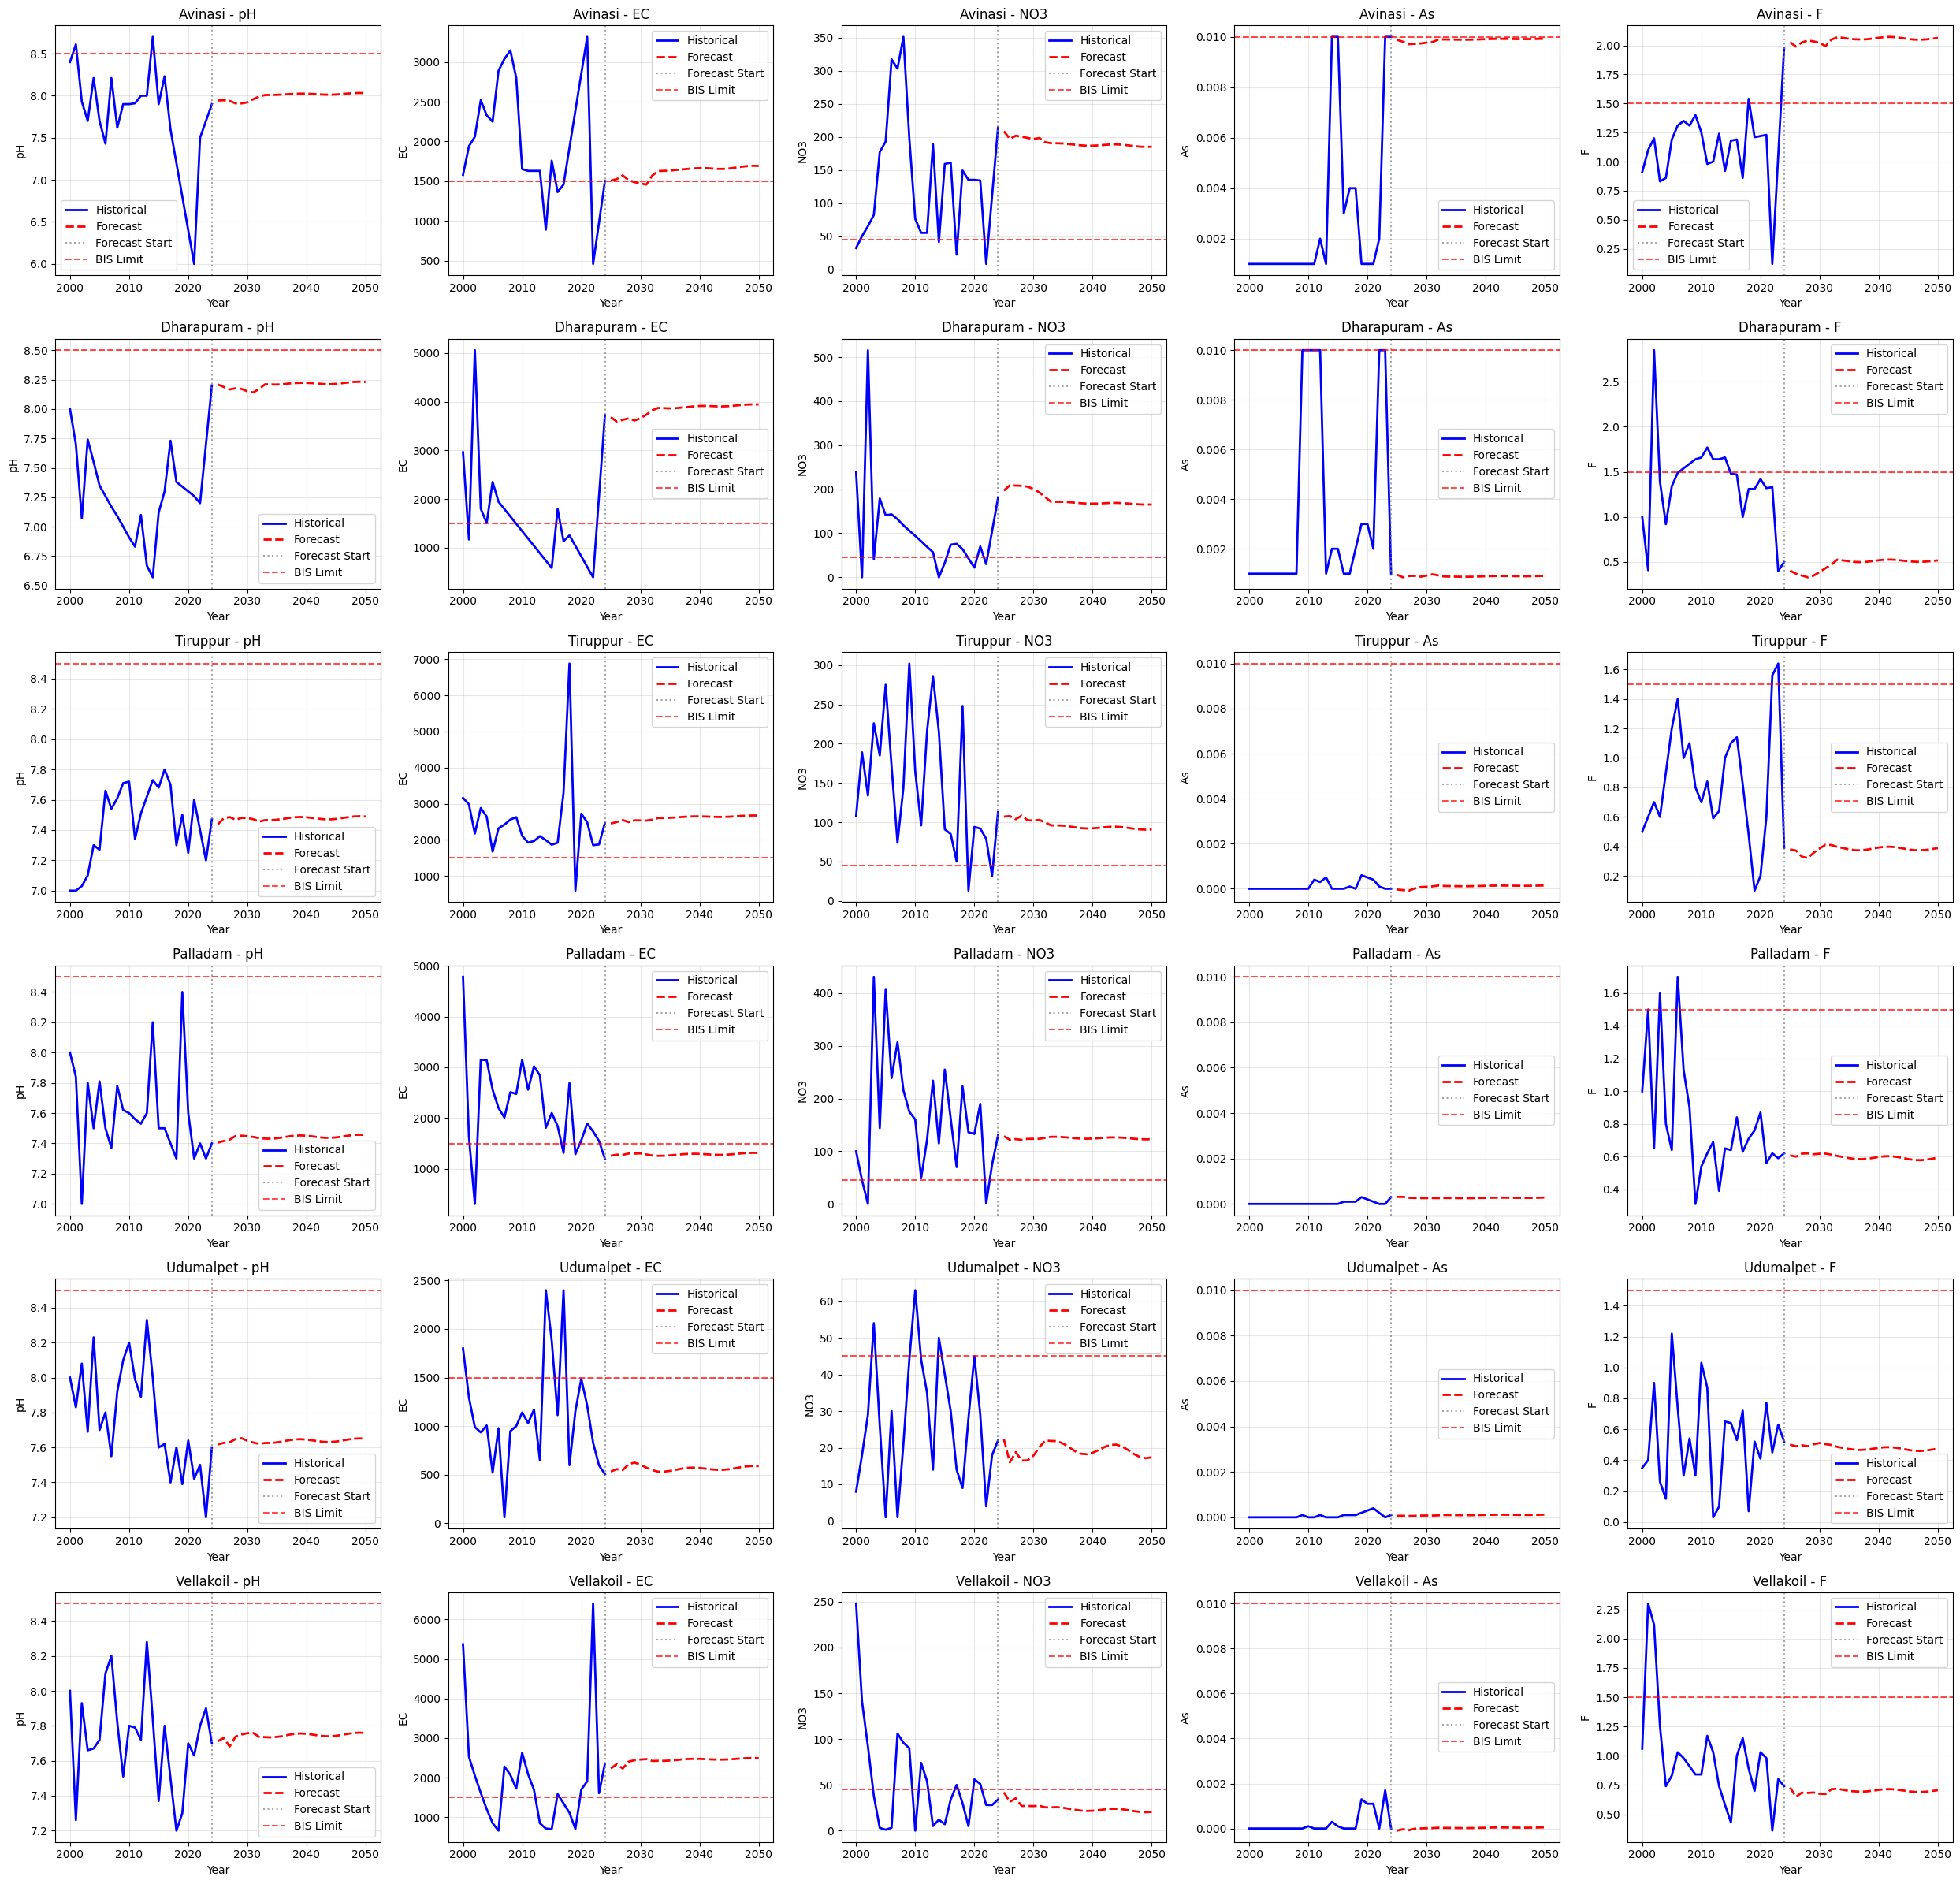

In [ ]:
# Visualize long-term forecasts
def plot_long_term_forecasts(forecast_df, villages_to_plot=None):
    if villages_to_plot is None:
        villages_to_plot = forecast_df['Village'].unique()[:6]  # Plot first 6 villages

    n_villages = len(villages_to_plot)
    fig, axes = plt.subplots(n_villages, len(target_parameters), figsize=(25, 4*n_villages))

    if n_villages == 1:
        axes = [axes]

    for i, village in enumerate(villages_to_plot):
        village_data = forecast_df[forecast_df['Village'] == village]

        for j, param in enumerate(target_parameters):
            if n_villages > 1:
                ax = axes[i, j]
            else:
                ax = axes[j]

            # Plot historical and forecast
            historical = village_data[village_data['Year'] <= 2024]
            forecast = village_data[village_data['Year'] >= 2025]

            ax.plot(historical['Year'], historical[param], 'b-', linewidth=2, label='Historical')
            ax.plot(forecast['Year'], forecast[param], 'r--', linewidth=2, label='Forecast')
            ax.axvline(x=2024, color='gray', linestyle=':', alpha=0.7, label='Forecast Start')

            # Add BIS limits
            if param in bis_standards:
                if 'max' in bis_standards[param]:
                    ax.axhline(y=bis_standards[param]['max'], color='red',
                              linestyle='--', alpha=0.7, label='BIS Limit')
                else:
                    ax.axhline(y=bis_standards[param]['min'], color='red',
                              linestyle='--', alpha=0.7, label='BIS Min')
                    ax.axhline(y=bis_standards[param]['max'], color='red',
                              linestyle='--', alpha=0.7, label='BIS Max')

            ax.set_title(f'{village} - {param}')
            ax.set_xlabel('Year')
            ax.set_ylabel(param)
            ax.legend()
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot forecasts for selected villages
selected_villages = ['Avinasi', 'Dharapuram', 'Tiruppur', 'Palladam', 'Udumalpet', 'Vellakoil']
plot_long_term_forecasts(df_final_forecast, selected_villages)

In [ ]:
# Trend analysis and risk assessment
def analyze_forecast_trends(forecast_df):
    trend_results = []

    for village in forecast_df['Village'].unique():
        village_data = forecast_df[forecast_df['Village'] == village].sort_values('Year')
        forecast_period = village_data[village_data['Year'] >= 2025]

        if len(forecast_period) > 1:
            village_trend = {'Village': village}

            for param in target_parameters:
                # Calculate trend (slope)
                years = forecast_period['Year'].values
                values = forecast_period[param].values
                slope = np.polyfit(years, values, 1)[0]

                # Risk assessment
                risk_level = "Low"
                if param in bis_standards:
                    current_value = forecast_period[param].iloc[-1]
                    if 'max' in bis_standards[param]:
                        if current_value > bis_standards[param]['max']:
                            risk_level = "High"
                        elif current_value > bis_standards[param]['max'] * 0.8:
                            risk_level = "Medium"
                    else:  # pH
                        if current_value < bis_standards[param]['min'] or current_value > bis_standards[param]['max']:
                            risk_level = "High"
                        elif (current_value < bis_standards[param]['min'] * 1.1 or
                              current_value > bis_standards[param]['max'] * 0.9):
                            risk_level = "Medium"

                village_trend[f'{param}_trend'] = slope
                village_trend[f'{param}_risk'] = risk_level
                village_trend[f'{param}_2050'] = forecast_period[param].iloc[-1]

            trend_results.append(village_trend)

    return pd.DataFrame(trend_results)

trend_analysis = analyze_forecast_trends(df_final_forecast)
print("=== TREND ANALYSIS AND RISK ASSESSMENT ===")
print(trend_analysis.round(4))

# Identify high-risk villages
high_risk_villages = {}
for param in target_parameters:
    high_risk = trend_analysis[trend_analysis[f'{param}_risk'] == 'High']['Village'].tolist()
    if high_risk:
        high_risk_villages[param] = high_risk
        print(f"\nHigh risk for {param}: {high_risk}")

=== TREND ANALYSIS AND RISK ASSESSMENT ===
         Village  pH_trend pH_risk  pH_2050  EC_trend EC_risk    EC_2050  \
0        Avinasi    0.0044  Medium   8.0310    8.2802    High  1692.3751   
1     Dharapuram    0.0025  Medium   8.2303   13.4895    High  3943.3231   
2   Gudimangalam    0.0020  Medium   7.3421    2.8200    High  1783.0452   
3       Kangeyam    0.0015  Medium   7.4663    6.5382    High  2164.7662   
4       Kundadam    0.0014  Medium   7.9837    6.5202    High  2089.0604   
5   Madathukulam    0.0017  Medium   7.6868    4.8310    High  1642.9828   
6       Moolanur    0.0013  Medium   7.3791    7.7291    High  2309.0787   
7       Palladam    0.0010  Medium   7.4556    1.1292  Medium  1315.2460   
8       Pongalur    0.0009  Medium   7.4633    0.9716    High  2774.3061   
9       Tiruppur    0.0008  Medium   7.4895    7.5086    High  2671.9944   
10     Udumalpet    0.0007  Medium   7.6500    0.3706     Low   587.1306   
11     Uttukkuli    0.0010  Medium   7.4442  

In [ ]:
# Create comprehensive forecast report
def generate_forecast_report(forecast_df, trend_df):
    print("="*60)
    print("WATER QUALITY FORECAST REPORT 2025-2050")
    print("="*60)

    # Summary statistics
    final_year_data = forecast_df[forecast_df['Year'] == 2050]

    print(f"\nSUMMARY FOR 2050:")
    for param in target_parameters:
        avg_value = final_year_data[param].mean()
        min_value = final_year_data[param].min()
        max_value = final_year_data[param].max()

        print(f"{param}: Avg={avg_value:.3f}, Min={min_value:.3f}, Max={max_value:.3f}")

    # Critical violations in 2050
    print(f"\nCRITICAL VIOLATIONS IN 2050:")
    for param in target_parameters:
        if param in bis_standards:
            if 'max' in bis_standards[param]:
                violations = (final_year_data[param] > bis_standards[param]['max']).sum()
            else:
                violations = ((final_year_data[param] < bis_standards[param]['min']) |
                             (final_year_data[param] > bis_standards[param]['max'])).sum()

            if violations > 0:
                print(f"  {param}: {violations} villages violating BIS standards")

    # Most improved parameters
    print(f"\nTREND ANALYSIS:")
    for param in target_parameters:
        improving = trend_df[trend_df[f'{param}_trend'] < 0].shape[0]
        worsening = trend_df[trend_df[f'{param}_trend'] > 0].shape[0]
        print(f"  {param}: {improving} villages improving, {worsening} villages worsening")

    # Recommendations
    print(f"\nKEY RECOMMENDATIONS:")
    if high_risk_villages:
        for param, villages in high_risk_villages.items():
            print(f"  • Immediate action needed for {param} in: {', '.join(villages[:3])}{'...' if len(villages) > 3 else ''}")
    else:
        print("  • Overall water quality trends are stable. Continue current monitoring practices.")

# Generate final report
generate_forecast_report(df_final_forecast, trend_analysis)

# Save forecasts to CSV
forecast_export = df_final_forecast[df_final_forecast['Year'] >= 2025][
    ['Village', 'Year', 'Latitude', 'Longtitude'] + target_parameters
]
forecast_export.to_csv('water_quality_forecast_2025_2050.csv', index=False)
print(f"\nForecasts saved to 'water_quality_forecast_2025_2050.csv'")

WATER QUALITY FORECAST REPORT 2025-2050

SUMMARY FOR 2050:
pH: Avg=7.645, Min=7.342, Max=8.230
EC: Avg=2119.332, Min=587.131, Max=3943.323
NO3: Avg=118.510, Min=-8.244, Max=334.994
As: Avg=0.001, Min=0.000, Max=0.010
F: Avg=0.776, Min=0.388, Max=2.064

CRITICAL VIOLATIONS IN 2050:
  EC: 11 villages violating BIS standards
  NO3: 9 villages violating BIS standards
  F: 1 villages violating BIS standards

TREND ANALYSIS:
  pH: 0 villages improving, 13 villages worsening
  EC: 0 villages improving, 13 villages worsening
  NO3: 13 villages improving, 0 villages worsening
  As: 2 villages improving, 11 villages worsening
  F: 7 villages improving, 6 villages worsening

KEY RECOMMENDATIONS:
  • Immediate action needed for EC in: Avinasi, Dharapuram, Gudimangalam...
  • Immediate action needed for NO3 in: Avinasi, Dharapuram, Gudimangalam...
  • Immediate action needed for F in: Avinasi

Forecasts saved to 'water_quality_forecast_2025_2050.csv'
